In [1]:
from pathlib import Path
import sys

# Add project root to path
ROOT = Path(".").resolve()
sys.path.insert(0, str(ROOT))

PATH    = ROOT / "data" / "bpic_12_A.xes"
CACHE   = ROOT / "cache"
RESULTS = ROOT / "results"

CACHE.mkdir(exist_ok=True)
RESULTS.mkdir(exist_ok=True)

print("Data file exists:", PATH.exists())

Data file exists: True


In [2]:

import pm4py

log = pm4py.read_xes(str(PATH))
print(f"Events: {len(log):,}")
print(f"Cases:  {log['case:concept:name'].nunique():,}")
print(f"Period: {log['time:timestamp'].min()} → {log['time:timestamp'].max()}")
log.head()

/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pm4py/utils.py:1027: UserWarning: Install the optional requirement `r4pm` to import/export files faster. `rustxes` remains supported as a fallback.
  warnings.warn(
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/pm4py/util/dt_parsing/parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(
/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
parsing log, completed traces :: 100%|██████████| 13087/13087 [00:01<00:00, 8747.09it/s]


Events: 60,849
Cases:  13,087
Period: 2011-09-30 22:38:44.546000+00:00 → 2012-03-14 14:33:57.651000+00:00


,Unnamed: 0,org:resource,lifecycle:transition,concept:name,time:timestamp,case:REG_DATE,case:concept:name,case:AMOUNT_REQ
0,0,112,COMPLETE,A_SUBMITTED,2011-09-30 22:38:44.546000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
1,1,112,COMPLETE,A_PARTLYSUBMITTED,2011-09-30 22:38:44.880000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
2,2,112,COMPLETE,A_PREACCEPTED,2011-09-30 22:39:37.906000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
3,3,10862,COMPLETE,A_ACCEPTED,2011-10-01 09:42:43.308000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000
4,4,10862,COMPLETE,A_FINALIZED,2011-10-01 09:45:09.243000+00:00,2011-10-01 00:38:44.546000+02:00,173688,20000


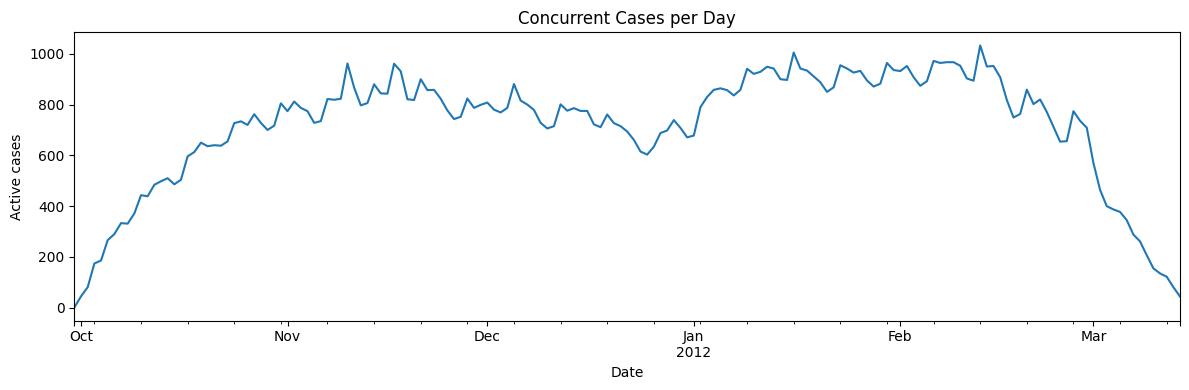

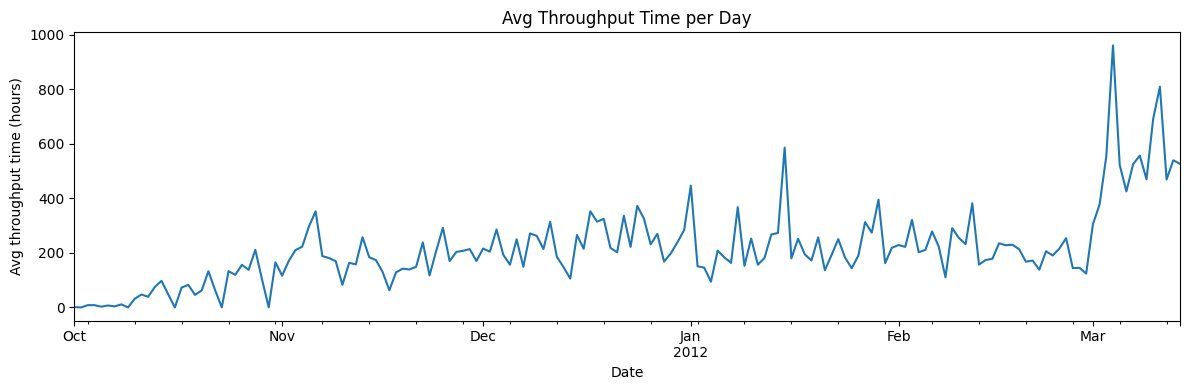

In [3]:
from time_series_creation import *
avg_cc=create_concurrent_cases_timeseries(log)
avg_tt=create_avg_throughtput_time_timeseries(log)

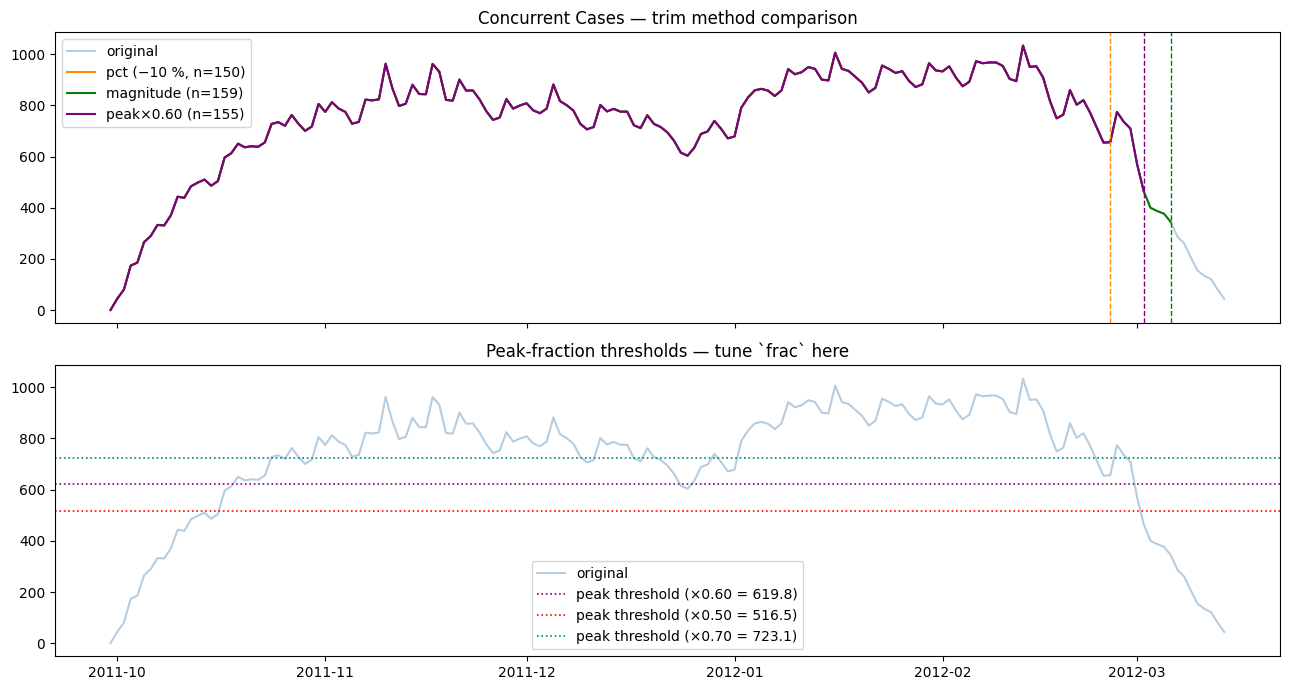

In [4]:
from time_series_preprocessing import *
from setttings import *
# ── diagnostic: compare all trim methods on avg_cc ───────────────────────────
_cc_pct = trim_tail_pct(avg_cc, pct=0.10)
_cc_mag = trim_tail_magnitude(avg_cc, k=1.5, window=7)
_cc_pk  = trim_tail_peak(avg_cc, frac=0.60, window=7)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(avg_cc.index, avg_cc, color="steelblue", alpha=0.4, label="original")
ax.plot(_cc_pct.index, _cc_pct, color="darkorange", label=f"pct (−10 %, n={len(_cc_pct)})")
ax.plot(_cc_mag.index, _cc_mag, color="green",      label=f"magnitude (n={len(_cc_mag)})")
ax.plot(_cc_pk.index,  _cc_pk,  color="purple",     label=f"peak×0.60 (n={len(_cc_pk)})")
for s, c in [(_cc_pct, "darkorange"), (_cc_mag, "green"), (_cc_pk, "purple")]:
    ax.axvline(s.index[-1], linestyle="--", color=c, linewidth=1)
ax.set_title("Concurrent Cases — trim method comparison")
ax.legend()

ax = axes[1]
ax.plot(avg_cc.index, avg_cc, color="steelblue", alpha=0.4, label="original")
ax.axhline(0.60 * avg_cc.max(), linestyle=":", color="purple",  linewidth=1.2, label=f"peak threshold (×0.60 = {0.60*avg_cc.max():.1f})")
ax.axhline(0.50 * avg_cc.max(), linestyle=":", color="red",     linewidth=1.2, label=f"peak threshold (×0.50 = {0.50*avg_cc.max():.1f})")
ax.axhline(0.70 * avg_cc.max(), linestyle=":", color="teal",    linewidth=1.2, label=f"peak threshold (×0.70 = {0.70*avg_cc.max():.1f})")
ax.set_title("Peak-fraction thresholds — tune `frac` here")
ax.legend()

plt.tight_layout()
plt.show()

CC: 167 → 125  (dropped 42 rows)
TT: 166 → 124  (dropped 42 rows)

CC  — train: 87, val: 12, test: 26
TT  — train: 86, val: 12, test: 26


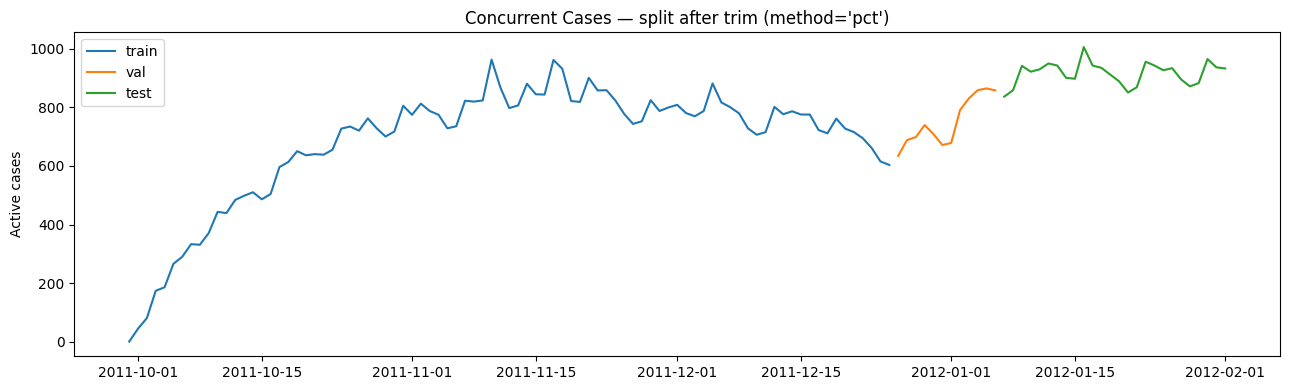

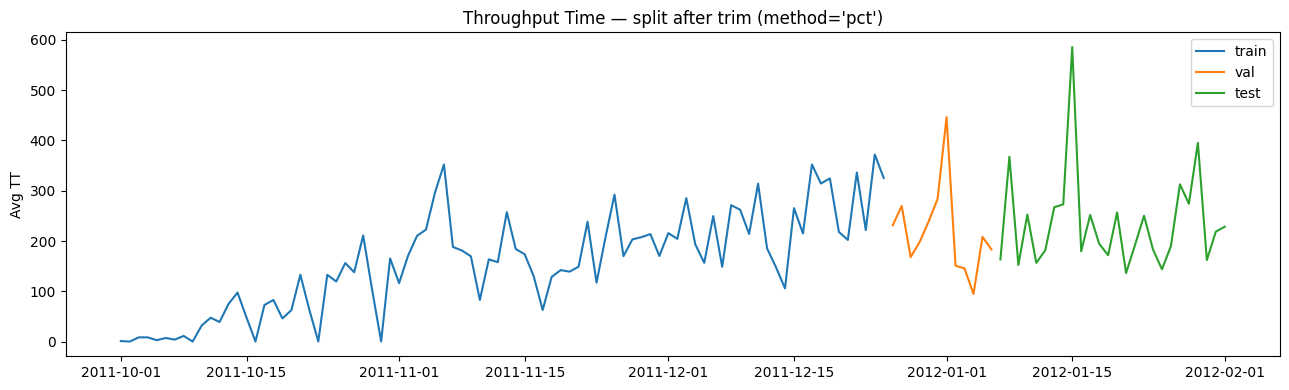

In [5]:
# ── truncation parameters ─────────────────────────────────────────────────────
TRIM_METHOD = "pct"    # "pct" | "magnitude" | "peak" | None
TRIM_PCT    = 0.25      # used when method="pct"
TRIM_K      = 1.5       # used when method="magnitude"
TRIM_FRAC   = 0.60      # used when method="peak": cut below frac * max
TRIM_WINDOW = 7         # rolling window (all methods)

set_global_seed(1904)
cfg = Split3WayConfig(train_frac=0.7, val_frac=0.1, test_frac=0.2)

avg_cc_trim = apply_trim(avg_cc, TRIM_METHOD, pct=TRIM_PCT, k=TRIM_K, frac=TRIM_FRAC, window=TRIM_WINDOW)
avg_tt_trim = apply_trim(avg_tt, TRIM_METHOD, pct=TRIM_PCT, k=TRIM_K, frac=TRIM_FRAC, window=TRIM_WINDOW)

print(f"CC: {len(avg_cc)} → {len(avg_cc_trim)}  (dropped {len(avg_cc) - len(avg_cc_trim)} rows)")
print(f"TT: {len(avg_tt)} → {len(avg_tt_trim)}  (dropped {len(avg_tt) - len(avg_tt_trim)} rows)")

train_cc, val_cc, test_cc = split_timeseries(avg_cc_trim, cfg)
train_tt, val_tt, test_tt = split_timeseries(avg_tt_trim, cfg)

print(f"\nCC  — train: {len(train_cc)}, val: {len(val_cc)}, test: {len(test_cc)}")
print(f"TT  — train: {len(train_tt)}, val: {len(val_tt)}, test: {len(test_tt)}")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_cc.index, train_cc, label="train")
ax.plot(val_cc.index,   val_cc,   label="val")
ax.plot(test_cc.index,  test_cc,  label="test")
ax.set_title(f"Concurrent Cases — split after trim (method={TRIM_METHOD!r})")
ax.set_ylabel("Active cases")
ax.legend()
plt.tight_layout()
plt.show()
plt.close()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(train_tt.index, train_tt, label="train")
ax.plot(val_tt.index,   val_tt,   label="val")
ax.plot(test_tt.index,  test_tt,  label="test")
ax.set_title(f"Throughput Time — split after trim (method={TRIM_METHOD!r})")
ax.set_ylabel("Avg TT")
ax.legend()
plt.tight_layout()
plt.show()

lw## Forecasting — Naive / ETS / SARIMAX

In [6]:
from time_series_prediction import (
    forecast_naive, forecast_naive_recent, forecast_seasonal_naive,
    forecast_ets, forecast_sarimax, forecast_ridge, forecast_gru, forecast_nbeats,
    tune_on_val, run_pipeline,
    SEASONAL_NAIVE_GRID, ETS_GRID, SARIMAX_GRID, RIDGE_GRID, GRU_GRID, NBEATS_GRID,
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

print(f"Seasonal naive grid: {len(SEASONAL_NAIVE_GRID)} candidates")
print(f"ETS grid:            {len(ETS_GRID)} candidates")
print(f"SARIMAX grid:        {len(SARIMAX_GRID)} candidates")
print(f"Ridge grid:          {len(RIDGE_GRID)} candidates")
print(f"GRU grid:            {len(GRU_GRID)} candidates")
print(f"N-BEATS grid:        {len(NBEATS_GRID)} candidates")

The StatsForecast module could not be imported. To enable support for the AutoARIMA, AutoETS and Croston models, please consider installing it.


Seasonal naive grid: 3 candidates
ETS grid:            30 candidates
SARIMAX grid:        16 candidates
Ridge grid:          12 candidates
GRU grid:            4 candidates
N-BEATS grid:        8 candidates


In [7]:
RIDGE_GRID

[{'lags': 7, 'alpha': 0.01, 'add_time_features': True},
 {'lags': 7, 'alpha': 0.1, 'add_time_features': True},
 {'lags': 7, 'alpha': 1.0, 'add_time_features': True},
 {'lags': 7, 'alpha': 10.0, 'add_time_features': True},
 {'lags': 14, 'alpha': 0.01, 'add_time_features': True},
 {'lags': 14, 'alpha': 0.1, 'add_time_features': True},
 {'lags': 14, 'alpha': 1.0, 'add_time_features': True},
 {'lags': 14, 'alpha': 10.0, 'add_time_features': True},
 {'lags': 28, 'alpha': 0.01, 'add_time_features': True},
 {'lags': 28, 'alpha': 0.1, 'add_time_features': True},
 {'lags': 28, 'alpha': 1.0, 'add_time_features': True},
 {'lags': 28, 'alpha': 10.0, 'add_time_features': True}]

In [8]:
preds_cc = run_pipeline(train_cc, val_cc, test_cc, label="ConcurrentCases")

[ConcurrentCases] Tuning seasonal_naive (3 candidates) …
  best: {'season': 30}  val_MSE=6665.2500
[ConcurrentCases] Tuning ets (30 candidates) …
  best: {'error': 'add', 'trend': 'mul', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=13194.7546
[ConcurrentCases] Tuning sarimax (16 candidates) …
  best: {'order': (1, 1, 1), 'seasonal_order': (0, 0, 0, 0)}  val_MSE=13952.6620
[ConcurrentCases] Tuning ridge (12 candidates) …
  best: {'lags': 7, 'alpha': 0.1, 'add_time_features': True}  val_MSE=9285.0801
[ConcurrentCases] Tuning ridge_mimo (12 candidates) …
  best: {'lags': 7, 'alpha': 10.0}  val_MSE=4825.1114
[ConcurrentCases] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.403865
  [GRU] epoch 2/50  loss=0.375543
  [GRU] epoch 3/50  loss=0.348757
  [GRU] epoch 4/50  loss=0.321521
  [GRU] epoch 5/50  loss=0.296635
  [GRU] epoch 6/50  loss=0.270670
  [GRU] epoch 7/50  loss=0.244816
  [GRU] epoch 8/50  loss=0.219435
  [GRU] epoch 9/50  loss=0.194065
  [GRU]

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 39.9 K | train | 0    
---------------------------------------------------------------------
37.4 K    Trainable params
2.5 K     Non-trainable params
39.9 K    Total params
0.160     Total estim

Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 45.78it/s, train_loss=0.00247]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 45.19it/s, train_loss=0.00247]


...

  best: {'input_chunk_length': 14, 'output_chunk_length': 14, 'hidden_size': 32, 'lstm_layers': 1, 'num_attention_heads': 4, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'epochs': 50, 'seed': 0}  val_MSE=8125.4792
Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 14.36it/s, train_loss=0.314]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 14.26it/s, train_loss=0.314]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 18.22it/s]

Model                      MSE         MAE
--------------------------------------------
naive                4921.8077     60.8077
seasonal_naive      44162.0385    198.1154
ets                  2433.9120     45.8791
sarimax              8982.0890     78.8667
ridge               73826.3627    265.6266
ridge_mimo          14099.4304    113.0149
gru                 12997.3566    103.9034
gru_mimo             4994.1978     60.1099
nbeats              10256.0475     92.8158
nhits               19586.0445    132.2972
tft                 25410.4545    146.4623


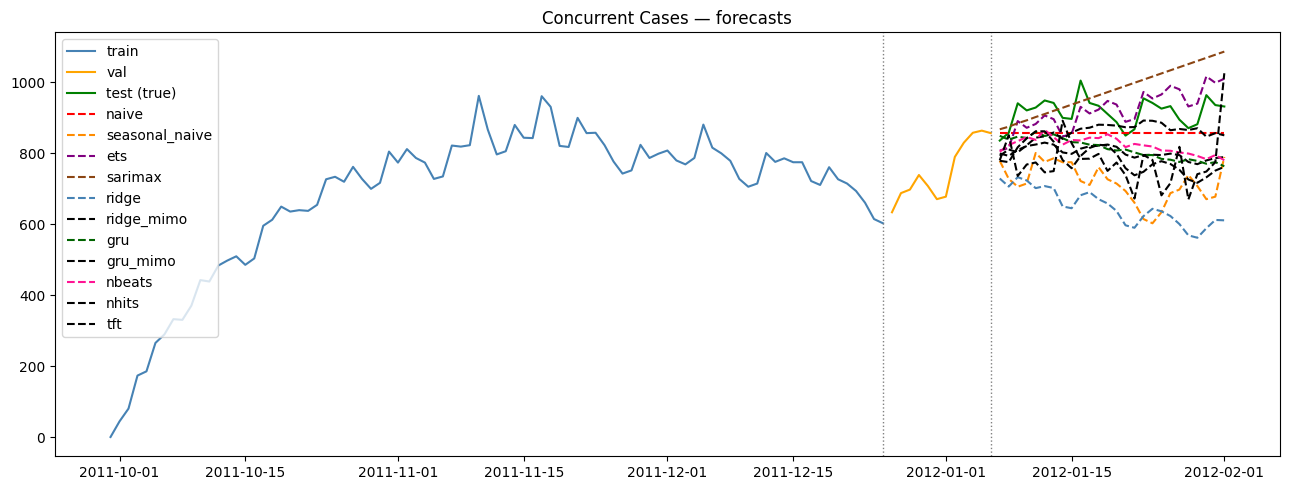

In [9]:
COLORS = {
    "naive":          "red",
    "naive_recent":   "salmon",
    "seasonal_naive": "darkorange",
    "ets":            "purple",
    "sarimax":        "saddlebrown",
    "ridge":          "steelblue",
    "gru":            "darkgreen",
    "nbeats":         "deeppink",
}

def plot_forecasts(train, val, test, preds, title, save_path=None):
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(train.index, train, color="steelblue", label="train")
    ax.plot(val.index,   val,   color="orange",    label="val")
    ax.plot(test.index,  test,  color="green",     label="test (true)", linewidth=1.5)
    for name, yhat in preds.items():
        ax.plot(test.index, yhat, linestyle="--", color=COLORS.get(name, "black"), label=name)
    ax.axvline(train.index[-1], linestyle=":", color="gray", linewidth=1)
    ax.axvline(val.index[-1],   linestyle=":", color="gray", linewidth=1)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        plt.close()
    else:
        plt.show()

plot_forecasts(train_cc, val_cc, test_cc, preds_cc, "Concurrent Cases — forecasts")

[ThroughputTime] Tuning seasonal_naive (3 candidates) …
  best: {'season': 30}  val_MSE=8762.7723
[ThroughputTime] Tuning ets (30 candidates) …


/Users/mi98gr/Documents/PhD/27_coding_local/06_System_level_prediction/.venv/lib/python3.10/site-packages/sklearn/metrics/_regression.py:584: RuntimeWarning: overflow encountered in square
  output_errors = _average((y_true - y_pred) ** 2, axis=0, weights=sample_weight)


  best: {'error': 'mul', 'trend': 'add', 'damped_trend': True, 'seasonal': 'add', 'seasonal_periods': 7}  val_MSE=5955.4048
[ThroughputTime] Tuning sarimax (16 candidates) …
  best: {'order': (1, 0, 0), 'seasonal_order': (1, 0, 0, 7)}  val_MSE=6010.2000
[ThroughputTime] Tuning ridge (12 candidates) …
  best: {'lags': 28, 'alpha': 0.1, 'add_time_features': True}  val_MSE=8383.7360
[ThroughputTime] Tuning ridge_mimo (12 candidates) …
  best: {'lags': 14, 'alpha': 10.0}  val_MSE=9705.8652
[ThroughputTime] Tuning gru (4 candidates) …
  [GRU] epoch 1/50  loss=0.755483
  [GRU] epoch 2/50  loss=0.737175
  [GRU] epoch 3/50  loss=0.721016
  [GRU] epoch 4/50  loss=0.706665
  [GRU] epoch 5/50  loss=0.691222
  [GRU] epoch 6/50  loss=0.677546
  [GRU] epoch 7/50  loss=0.664787
  [GRU] epoch 8/50  loss=0.651251
  [GRU] epoch 9/50  loss=0.636081
  [GRU] epoch 10/50  loss=0.622793
  [GRU] epoch 11/50  loss=0.607034
  [GRU] epoch 12/50  loss=0.593906
  [GRU] epoch 13/50  loss=0.578281
  [GRU] epoch 14/5

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name            | Type             | Params | Mode  | FLOPs
---------------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train | 0    
1 | train_criterion | MSELoss          | 0      | train | 0    
2 | val_criterion   | MSELoss          | 0      | train | 0    
3 | train_metrics   | MetricCollection | 0      | train | 0    
4 | val_metrics     | MetricCollection | 0      | train | 0    
5 | stacks          | ModuleList       | 39.9 K | train | 0    
---------------------------------------------------------------------
37.4 K    Trainable params
2.5 K     Non-trainable params
39.9 K    Total params
0.160     Total estim

Epoch 49: 100%|██████████| 3/3 [00:00<00:00, 11.82it/s, train_loss=0.0374]

...


  best: {'input_chunk_length': 14, 'output_chunk_length': 7, 'hidden_size': 32, 'lstm_layers': 1, 'num_attention_heads': 4, 'dropout': 0.1, 'lr': 0.001, 'batch_size': 32, 'epochs': 50, 'seed': 0}  val_MSE=5907.5687
Epoch 49: 100%|██████████| 3/3 [00:00<00:00,  6.90it/s, train_loss=0.646]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 3/3 [00:00<00:00,  6.85it/s, train_loss=0.646]


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  8.15it/s]

Model                      MSE         MAE
--------------------------------------------
naive               11947.5380     68.5260
seasonal_naive      17910.2603    110.4155
ets                  7805.4968     60.9341
sarimax             11828.9028     74.3693
ridge               46271.8184    175.4581
ridge_mimo           9645.5751     72.7584
gru                 10986.3114     75.6160
gru_mimo             9666.3785     66.9506
nbeats               8736.0025     72.7113
nhits               13341.7972     87.9084
tft                 10550.3773     73.7809


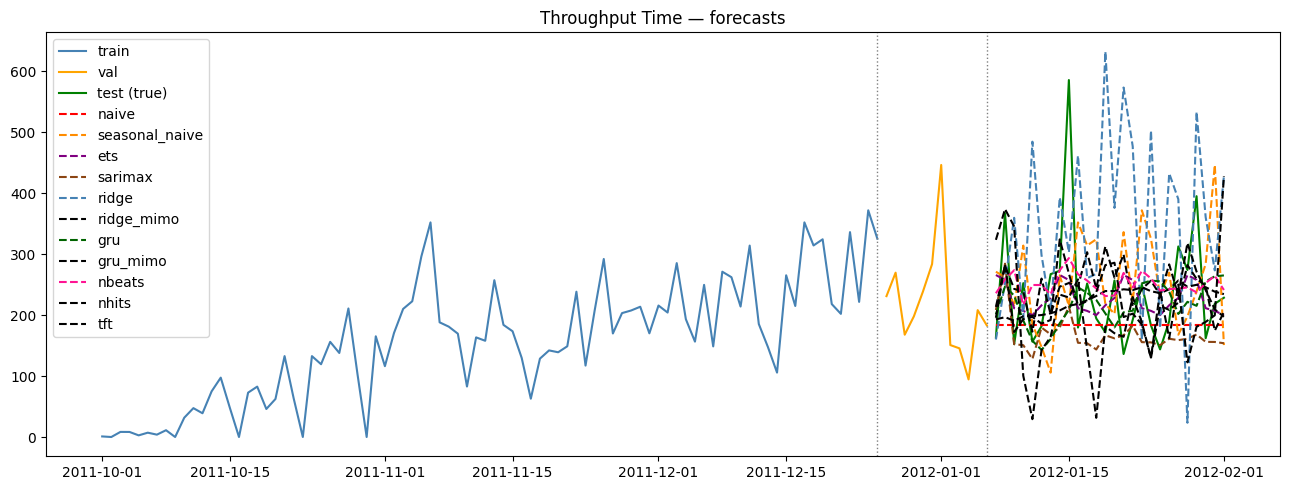

In [10]:
preds_tt = run_pipeline(train_tt, val_tt, test_tt, label="ThroughputTime")
plot_forecasts(train_tt, val_tt, test_tt, preds_tt, "Throughput Time — forecasts")

## Batch evaluation — all datasets

In [ ]:
import traceback
from pathlib import Path

import pandas as pd
import pm4py
from sklearn.metrics import mean_absolute_error, mean_squared_error

from time_series_creation import (
    create_concurrent_cases_timeseries,
    create_avg_throughtput_time_timeseries,
)
from time_series_preprocessing import apply_trim, split_timeseries
from time_series_prediction import run_pipeline


def evaluate_all_datasets(
    data_dir: str | Path,
    results_dir: str | Path,
    trim_method: str = "pct",
    trim_pct: float = 0.15,
    trim_k: float = 1.5,
    trim_frac: float = 0.60,
    trim_window: int = 7,
    train_frac: float = 0.7,
    val_frac: float = 0.1,
    test_frac: float = 0.2,
    models: list[str] | None = None,
    tuning: str = "small",
    include_naive_recent: bool = False,
    save_plots: bool = True,
) -> pd.DataFrame:
    """Run the full forecasting pipeline on every .xes file in data_dir.

    For each dataset, both concurrent_cases and throughput_time are evaluated.
    Per-model MSE and MAE on the test set are saved as CSVs under results_dir,
    and optionally a forecast plot PNG is saved alongside.

    Parameters
    ----------
    data_dir             : directory containing .xes event log files
    results_dir          : root directory where outputs are written
    trim_method          : tail-trimming method ("pct", "magnitude", "peak", None)
    trim_pct             : fraction to drop when trim_method="pct"
    trim_k               : std multiplier when trim_method="magnitude"
    trim_frac            : peak fraction when trim_method="peak"
    trim_window          : rolling window size for magnitude/peak methods
    train_frac           : fraction of trimmed series for training
    val_frac             : fraction for validation / HPO
    test_frac            : fraction for final evaluation
    models               : model subset; None runs all defaults (excludes naive_recent)
    tuning               : "small" or "large" grid search
    include_naive_recent : if True, also run the oracle naive_recent baseline
    save_plots           : if True, save a forecast PNG per series to results_dir

    Returns
    -------
    pd.DataFrame with columns: dataset, series, model, mse, mae
    """
    data_dir    = Path(data_dir)
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)

    cfg     = Split3WayConfig(train_frac=train_frac, val_frac=val_frac, test_frac=test_frac)
    trim_kw = dict(pct=trim_pct, k=trim_k, frac=trim_frac, window=trim_window)

    # build the effective models list
    if include_naive_recent:
        base = models if models is not None else [
            "naive", "seasonal_naive", "ets", "sarimax",
            "ridge", "ridge_mimo", "gru", "gru_mimo",
            "nbeats", "nhits", "tft",
        ]
        models_to_run = base + ["naive_recent"]
    else:
        models_to_run = models   # None → run_pipeline uses its own default (no naive_recent)

    all_rows: list[dict] = []

    xes_files = sorted(data_dir.glob("*.xes"))
    print(f"Found {len(xes_files)} dataset(s): {[f.stem for f in xes_files]}\n")

    series_map = {
        "concurrent_cases": create_concurrent_cases_timeseries,
        "throughput_time":  create_avg_throughtput_time_timeseries,
    }

    for xes_path in xes_files:
        dataset_name = xes_path.stem
        print(f"{'='*60}\nDataset: {dataset_name}\n{'='*60}")

        try:
            log = pm4py.read_xes(str(xes_path))
        except Exception:
            print(f"  [SKIP] failed to load:\n{traceback.format_exc()}")
            continue

        out_dir = results_dir / dataset_name
        out_dir.mkdir(parents=True, exist_ok=True)
        dataset_rows: list[dict] = []

        for series_name, series_fn in series_map.items():
            print(f"\n  -- {series_name} --")
            try:
                raw     = series_fn(log)
                trimmed = apply_trim(raw, trim_method, **trim_kw)
                print(f"  Trimmed: {len(raw)} → {len(trimmed)} observations")

                train, val, test = split_timeseries(trimmed, cfg)
                print(f"  Split: train={len(train)}, val={len(val)}, test={len(test)}")

                preds = run_pipeline(
                    train, val, test,
                    label=f"{dataset_name}/{series_name}",
                    models=models_to_run,
                    tuning=tuning,
                )

                if save_plots:
                    plot_forecasts(
                        train, val, test, preds,
                        title=f"{dataset_name} — {series_name}",
                        save_path=out_dir / f"{series_name}.png",
                    )

                y_test = test.to_numpy()
                for model_name, yhat in preds.items():
                    row = dict(
                        dataset=dataset_name,
                        series=series_name,
                        model=model_name,
                        mse=mean_squared_error(y_test, yhat),
                        mae=mean_absolute_error(y_test, yhat),
                    )
                    dataset_rows.append(row)
                    all_rows.append(row)

            except Exception:
                print(f"  [SKIP] {series_name} failed:\n{traceback.format_exc()}")
                continue

        if dataset_rows:
            pd.DataFrame(dataset_rows).to_csv(out_dir / "metrics.csv", index=False)
            print(f"\n  Saved → {out_dir}/metrics.csv" +
                  (f" + {series_name}.png" if save_plots else ""))

    results_df = pd.DataFrame(all_rows)
    if not results_df.empty:
        results_df.to_csv(results_dir / "metrics_all.csv", index=False)
        print(f"\nSaved combined → {results_dir}/metrics_all.csv")

    return results_df

In [ ]:
results = evaluate_all_datasets(
    data_dir    = ROOT / "data",
    results_dir = ROOT / "results",
    trim_method = "pct",
    trim_pct    = 0.15,
    tuning      = "small",
    # models    = ["naive", "ets", "sarimax"],  # uncomment to run a subset
)
results